In [1]:
import pandas as pd
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\usaan\Downloads\data_science_datasets\machine learning\supervised classification\binary\heart.csv")

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
data.shape

(918, 12)

In [5]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [6]:
data.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [8]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder,MinMaxScaler

In [10]:
Sex_encoded=LabelEncoder()

In [11]:
data["Sex"]=Sex_encoded.fit_transform(data["Sex"])

In [12]:
ChestPainType_encoded=LabelEncoder()

In [13]:
data["ChestPainType"]=ChestPainType_encoded.fit_transform(data["ChestPainType"])

In [14]:
RestingECG_encoded=LabelEncoder()

In [15]:
data["RestingECG"]=RestingECG_encoded.fit_transform(data["RestingECG"])

In [16]:
ExerciseAngina_encoded=LabelEncoder()

In [17]:
data["ExerciseAngina"]=ExerciseAngina_encoded.fit_transform(data["ExerciseAngina"])

In [18]:
ST_Slope_encoded=LabelEncoder()

In [19]:
data["ST_Slope"]=ST_Slope_encoded.fit_transform(data["ST_Slope"])

In [20]:
X=data[['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']].values

In [21]:
Y=data[['HeartDisease']].values

In [22]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [26]:
x_train.shape

(734, 11)

<Axes: ylabel='count'>

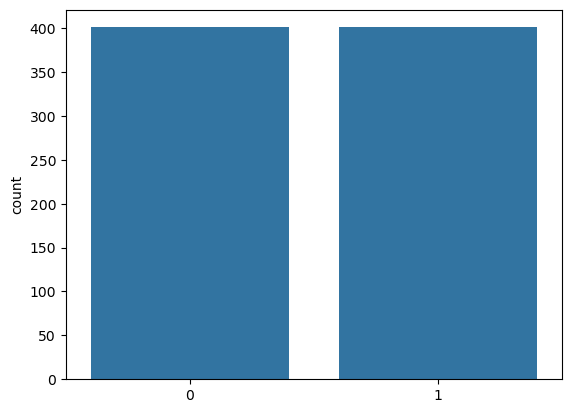

In [27]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)
sns.countplot(x=y_train)

In [28]:
mm=MinMaxScaler()

In [29]:
x_train=mm.fit_transform(x_train)

In [30]:
x_test=mm.transform(x_test)

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score
import numpy as np

In [32]:
models={
       "LogisticRegression":LogisticRegression(),
       "DecisionTreeClassifier":DecisionTreeClassifier(),
       "RandomForestClassifier":RandomForestClassifier(),
       "AdaBoostClassifier":AdaBoostClassifier(),
       "GradientBoostingClassifier":GradientBoostingClassifier(),
       "KNeighborsClassifier":KNeighborsClassifier(),
       "Naive Bayes":MultinomialNB(),
       "XGBClassifier":XGBClassifier()
}

In [33]:
for name,model in models.items():
    scores=cross_val_score(estimator=model,X=x_train,y=y_train,cv=5,scoring="accuracy")
    print(f"score:{np.mean(scores)},model={name}")
    print()

score:0.8366149068322981,model=LogisticRegression

score:0.8029813664596274,model=DecisionTreeClassifier

score:0.869083850931677,model=RandomForestClassifier

score:0.8515916149068323,model=AdaBoostClassifier

score:0.8690760869565217,model=GradientBoostingClassifier

score:0.8353726708074534,model=KNeighborsClassifier

score:0.7941847826086957,model=Naive Bayes

score:0.8690450310559006,model=XGBClassifier



In [34]:
from sklearn.model_selection import GridSearchCV

In [35]:
rf=RandomForestClassifier()

In [36]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [37]:
param={
    "n_estimators":[100,200,300,400,500],
    "max_depth":[1,2,3,4,5],
    "min_samples_leaf":[1,2,3,4,5],
    "min_samples_split":[2,3,4,5]
}

In [38]:
grid=GridSearchCV(estimator=rf,param_grid=param,cv=5,scoring="accuracy")

In [39]:
grid.fit(x_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [1, 2, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [40]:
print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [41]:
best_model = grid.best_estimator_
p = best_model.predict(x_test)

In [43]:
accuracy_score(y_test,p)

0.875

In [46]:
recall_score(y_test,p)

0.8691588785046729

In [47]:
print(classification_report(y_test,p))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86        77
           1       0.91      0.87      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.88      0.87       184
weighted avg       0.88      0.88      0.88       184



In [48]:
confusion_matrix(y_test,p)

array([[68,  9],
       [14, 93]])

In [49]:
import pickle

In [50]:
model_data={
    "model":best_model,
    "Sex_encoded":Sex_encoded,
    "ChestPainType_encoded":ChestPainType_encoded,
    "RestingECG_encoded":RestingECG_encoded,
    "ExerciseAngina_encoded":ExerciseAngina_encoded,
    "ST_Slope_encoded":ST_Slope_encoded,
    "minmax_scaler":mm
}

with open("Heart_Disease.pkl","wb") as file:
    pickle.dump(model_data,file)

In [51]:
loaded_model=pickle.load(open("Heart_Disease.pkl","rb"))

In [52]:
input_data=[[35,0,1,150,200,1,1,175,0,0.0,2]]

In [53]:
model=loaded_model["model"]

In [54]:
input_data = np.array(input_data).reshape(1, -1)
input_data = mm.transform(input_data)
prediction = best_model.predict(input_data)

In [55]:
print(prediction)

[0]


In [56]:
loaded_model=pickle.load(open(r"C:\Users\usaan\Saandra_FuturaLabs_Practice\Machine Learning\Heart Disease Prediction\Heart_Disease.pkl","rb"))

In [57]:
RestingECG_encoded.classes_


array(['LVH', 'Normal', 'ST'], dtype=object)